In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
# Loading the dataset into pandas DataFrame

df = pd.read_csv("ids.csv")

In [3]:
# Displaying first 5 records to check dataset loaded properly

df.head()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,53,62171,2,2,78,164,39,39,39.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,1,2710,48,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,2,443,4792909,5,1,135,46,46,6,27.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,3,80,115596470,75,82,342,118155,342,0,4.56,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,4,2910,14,2,2,4,12,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN


# Question 1: Data Understanding

The dataset used in this coursework is a network traffic dataset. It contains different network flow features such as destination port, flow duration, packet counts, packet lengths, flow bytes per second, flow packets per second, and other statistical measurements of network traffic.

The main purpose of this dataset is to understand the characteristics of network traffic and prepare the data for further data mining and classification. The Label column identifies whether the traffic is normal or attack traffic.

In this dataset, BENIGN represents normal traffic, while Infiltration represents attack traffic.

## Important Columns in the Dataset

- **Destination Port:** Shows the destination port number used in the network connection.
- **Flow Duration:** Shows the total duration of the network flow.
- **Total Fwd Packets:** Shows the number of packets sent in the forward direction.
- **Total Backward Packets:** Shows the number of packets sent in the backward direction.
- **Total Length of Fwd Packets:** Shows the total length of packets in the forward direction.
- **Total Length of Bwd Packets:** Shows the total length of packets in the backward direction.
- **Fwd Packet Length Mean:** Shows the average length of packets in the forward direction.
- **Bwd Packet Length Mean:** Shows the average length of packets in the backward direction.
- **Flow Bytes/s:** Shows the number of bytes transferred per second.
- **Flow Packets/s:** Shows the number of packets transferred per second.
- **Packet Length Mean:** Shows the average packet length.
- **Packet Length Std:** Shows the variation in packet length.
- **Average Packet Size:** Shows the average packet size in the flow.
- **Active Mean:** Shows the average active time of the flow.
- **Idle Mean:** Shows the average idle time of the flow.
- **Label:** Shows whether the traffic is normal or attack traffic.

In [4]:
# Checking total number of rows and columns

df.shape

(488115, 80)

In [5]:
# Displaying basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   488115 non-null  int64  
 1   Destination Port             488115 non-null  int64  
 2   Flow Duration                488115 non-null  int64  
 3   Total Fwd Packets            488115 non-null  int64  
 4   Total Backward Packets       488115 non-null  int64  
 5   Total Length of Fwd Packets  488115 non-null  int64  
 6   Total Length of Bwd Packets  488115 non-null  int64  
 7   Fwd Packet Length Max        488115 non-null  int64  
 8   Fwd Packet Length Min        488115 non-null  int64  
 9   Fwd Packet Length Mean       488115 non-null  float64
 10  Fwd Packet Length Std        488115 non-null  float64
 11  Bwd Packet Length Max        488115 non-null  int64  
 12  Bwd Packet Length Min        488115 non-null  int64  
 13 

In [6]:
# Displaying all column names in the dataset

df.columns

Index(['Unnamed: 0', 'Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
     

In [7]:
# Counting the number of records in each Label category

df['Label'].value_counts()

Label
BENIGN          288566
Infiltration    199549
Name: count, dtype: int64

# Question 2: Data Preparation

In this section, the dataset is prepared for analysis. The required columns are selected from the original dataset, missing values are checked and removed, duplicate records are checked and dropped, and the Label column values are renamed into more understandable categories.

In [8]:
# Displaying last 50 records of the original dataset

df.tail(50)

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,488065,53,70591,2,2,66,194,33,33,33.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,488066,443,5572560,8,6,386,5205,205,0,48.250000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,488067,3013,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,488068,53,122130,2,2,80,272,40,40,40.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,488069,53,98106274,2,2,114,211,58,56,57.000000,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,488070,53,506,1,1,53,113,53,53,53.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,488071,53,3957631,2,2,120,260,79,41,60.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,488072,9102,2,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,488073,2135,111,2,2,4,12,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,488074,1048,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


In [9]:
# Creating a new DataFrame with only the required columns

columns = ['Destination Port', 'Flow Duration', 'Total Fwd Packets',
           'Total Backward Packets', 'Total Length of Fwd Packets',
           'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
           'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
           'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
           'Active Mean', 'Idle Mean', 'Label']

new_df = df[columns]

new_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN


In [10]:
# Showing total number of columns in the new DataFrame

len(new_df.columns)

16

In [11]:
# Displaying names of all columns in the new DataFrame

new_df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
       'Active Mean', 'Idle Mean', 'Label'],
      dtype='object')

In [12]:
# Checking missing values in the new DataFrame

new_df.isna().sum()

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64

In [13]:
# Removing missing values from the new DataFrame

new_df = new_df.dropna()

In [14]:
# Checking missing values again after removing them
new_df.isna().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Length Mean         0
Flow Bytes/s                   0
Flow Packets/s                 0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Label                          0
dtype: int64

In [15]:
# Checking total number of duplicate records

new_df.duplicated().sum()

np.int64(139389)

In [16]:
# Dropping duplicate records

new_df = new_df.drop_duplicates()

In [17]:
# Checking shape after dropping duplicate records
new_df.shape

(348690, 16)

In [18]:
# Renaming values in the Label column

new_df['Label'] = new_df['Label'].replace({
    'BENIGN': 'Normal Traffic',
    'Infiltration': 'Attack'
})

In [19]:
# Checking Label values after renaming
new_df['Label'].value_counts()

Label
Normal Traffic    228462
Attack            120228
Name: count, dtype: int64

In [20]:
# Checking data types of selected columns

new_df.dtypes

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
Total Length of Bwd Packets      int64
Fwd Packet Length Mean         float64
Bwd Packet Length Mean         float64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Packet Length Mean             float64
Packet Length Std              float64
Average Packet Size            float64
Active Mean                    float64
Idle Mean                      float64
Label                           object
dtype: object

# Question 3: Data Analysis

In this section, summary statistics are calculated for two selected numeric variables. Correlation analysis is also performed to understand the relationship between numeric variables in the prepared dataset.

In [21]:
# Selecting two numeric variables for summary statistics

selected_variables = new_df[['Flow Duration', 'Packet Length Mean']]

selected_variables.head()

,Flow Duration,Packet Length Mean
0,62171,56.200000
1,48,2.000000
2,4792909,32.428571
3,115596470,749.981013
4,14,3.600000


In [22]:
# Calculating summary statistics for selected numeric variables

summary_statistics = selected_variables.agg(['sum', 'mean', 'std', 'skew', 'kurt'])

summary_statistics

,Flow Duration,Packet Length Mean
sum,3.871283e+12,3.540654e+07
mean,1.110236e+07,1.015416e+02
std,3.025305e+07,1.892582e+02
skew,2.825216e+00,4.480638e+00
kurt,6.546826e+00,2.847162e+01


The summary statistics show the overall behaviour of Flow Duration and Packet Length Mean. The mean shows the average value, standard deviation shows how spread out the values are, skewness shows whether the data is tilted to one side, and kurtosis shows the sharpness of the distribution.

## Correlation Analysis

Correlation is used to measure the relationship between numeric variables. A positive correlation means both variables increase together, while a negative correlation means one variable decreases when the other increases.

In [23]:
# Selecting only numeric columns for correlation analysis

numeric_df = new_df.select_dtypes(include=['int64', 'float64'])

numeric_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0


In [24]:
# Calculating correlation of all numeric variables

correlation = numeric_df.corr()

correlation

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean
Destination Port,1.000000,-0.167055,-0.028559,-0.026446,0.004126,-0.017241,0.002400,-0.244085,0.069395,0.303341,-0.136356,-0.183775,-0.146206,-0.059204,-0.125010
Flow Duration,-0.167055,1.000000,0.118145,0.094555,0.030323,0.059268,0.098978,0.332114,-0.019685,-0.104314,0.305610,0.449331,0.282393,0.200490,0.647140
Total Fwd Packets,-0.028559,0.118145,1.000000,0.949062,0.343939,0.916230,0.033070,0.202645,-0.002430,-0.018426,0.193839,0.167640,0.183904,0.137156,0.070066
Total Backward Packets,-0.026446,0.094555,0.949062,1.000000,0.149253,0.960826,0.012643,0.193250,-0.002815,-0.017508,0.179551,0.149349,0.170510,0.100654,0.061522
Total Length of Fwd Packets,0.004126,0.030323,0.343939,0.149253,1.000000,0.012884,0.123802,0.013617,0.001583,-0.005580,0.076610,0.051213,0.074531,0.059281,0.011872
Total Length of Bwd Packets,-0.017241,0.059268,0.916230,0.960826,0.012884,1.000000,-0.003013,0.190349,-0.001374,-0.010661,0.172088,0.133728,0.163848,0.078025,0.045712
Fwd Packet Length Mean,0.002400,0.098978,0.033070,0.012643,0.123802,-0.003013,1.000000,0.100914,0.153631,-0.059130,0.603530,0.451502,0.619437,0.063359,0.061425
Bwd Packet Length Mean,-0.244085,0.332114,0.202645,0.193250,0.013617,0.190349,0.100914,1.000000,-0.025433,-0.149707,0.818627,0.871980,0.801757,0.182490,0.219123
Flow Bytes/s,0.069395,-0.019685,-0.002430,-0.002815,0.001583,-0.001374,0.153631,-0.025433,1.000000,0.237830,0.128165,0.070184,0.190360,-0.006987,-0.014694
Flow Packets/s,0.303341,-0.104314,-0.018426,-0.017508,-0.005580,-0.010661,-0.059130,-0.149707,0.237830,1.000000,-0.111929,-0.127777,-0.108640,-0.037080,-0.077861


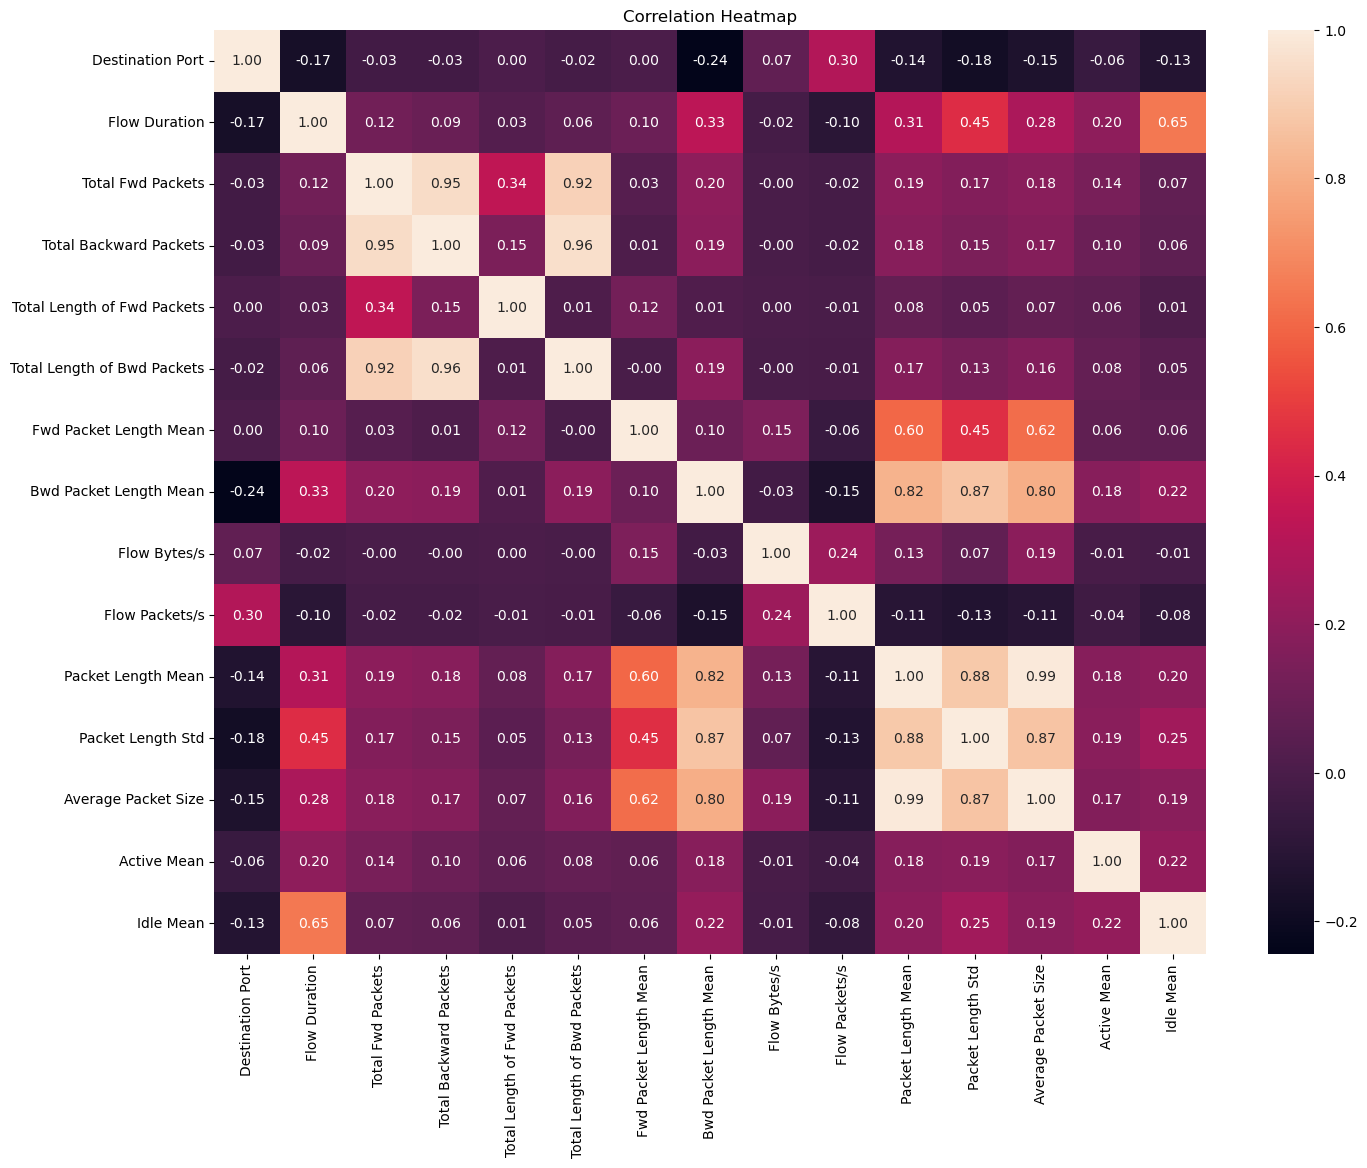

In [25]:
# Creating correlation heatmap

plt.figure(figsize=(16, 12))
sns.heatmap(new_df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Finding top 5 correlated feature pairs

correlation_pairs = correlation.unstack()

correlation_pairs = correlation_pairs.sort_values(ascending=False)

correlation_pairs = correlation_pairs[correlation_pairs < 1]

top_5_correlations = correlation_pairs.head(5)

top_5_correlations

Packet Length Mean           Average Packet Size            0.994985
Average Packet Size          Packet Length Mean             0.994985
Total Length of Bwd Packets  Total Backward Packets         0.960826
Total Backward Packets       Total Length of Bwd Packets    0.960826
Total Fwd Packets            Total Backward Packets         0.949062
dtype: float64

The top 5 correlated feature pairs show the strongest relationships between numeric variables. These relationships are useful because they help identify which network traffic features move together and may provide similar information during further data mining or classification.

# Question 4: Data Exploration

In this section, the prepared dataset is explored using visualizations and statistical testing. The Label column is analysed to check class balance, average Flow Duration and Packet Length Mean are compared by traffic category, a boxplot is created for Fwd Packet Length Mean, and a hypothesis test is performed for Flow Duration.

In [27]:
# Counting frequency of each Label category

label_counts = new_df['Label'].value_counts()

label_counts

Label
Normal Traffic    228462
Attack            120228
Name: count, dtype: int64

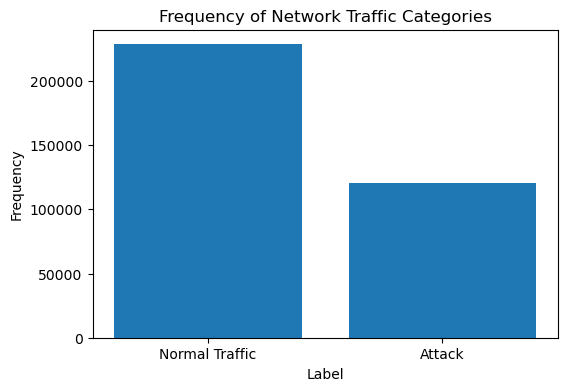

In [28]:
# Plotting bar chart for Label frequency

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Frequency of Network Traffic Categories")
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.show()

The bar chart shows the frequency of Normal Traffic and Attack records in the dataset. From the result, Normal Traffic has more records than Attack traffic. This means the dataset is not perfectly balanced because both classes do not have equal number of records. However, both categories are still present in a large amount, which is useful for further analysis.

In [29]:
# Calculating average Flow Duration by Label

avg_flow_duration = new_df.groupby('Label')['Flow Duration'].mean()

avg_flow_duration

Label
Attack            1.072047e+07
Normal Traffic    1.130334e+07
Name: Flow Duration, dtype: float64

In [30]:
# Finding category with highest average Flow Duration

highest_flow_duration = avg_flow_duration.idxmax()
highest_flow_duration

'Normal Traffic'

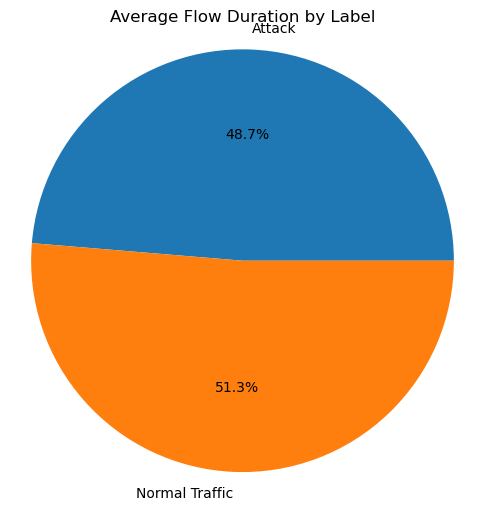

In [31]:
# Pie chart for average Flow Duration by Label
plt.figure(figsize=(6, 6))
plt.pie(avg_flow_duration.values, labels=avg_flow_duration.index, autopct="%1.1f%%")
plt.title("Average Flow Duration by Label")
plt.axis('equal')
plt.show()

In [32]:
# Calculating average Packet Length Mean by Label

avg_packet_length = new_df.groupby('Label')['Packet Length Mean'].mean()

avg_packet_length

Label
Attack             98.773547
Normal Traffic    102.998278
Name: Packet Length Mean, dtype: float64

In [33]:
# Finding category with highest average Packet Length Mean

highest_packet_length = avg_packet_length.idxmax()
highest_packet_length

'Normal Traffic'

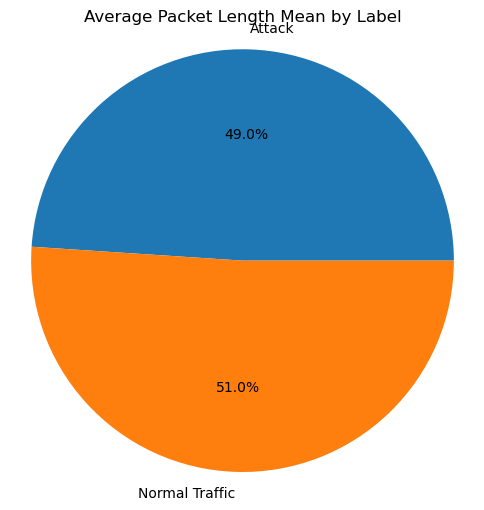

In [42]:
# Pie chart for average Packet Length Mean by Label
plt.figure(figsize=(6, 6))
plt.pie(avg_packet_length.values, labels=avg_packet_length.index, autopct="%1.1f%%")
plt.title("Average Packet Length Mean by Label")
plt.axis('equal')
plt.show()

The average Flow Duration and average Packet Length Mean are compared between Normal Traffic and Attack categories. These comparisons help to identify which traffic category has higher network flow duration and higher average packet length. The pie charts are used only for visual comparison, while the actual average values are shown in the output tables above the charts.

## Boxplot After Removing Outliers

Outliers are removed only from the Fwd Packet Length Mean column to make the boxplot clearer and easier to interpret. A separate DataFrame is created for the boxplot so that the main prepared dataset remains unchanged for other analysis.

In [35]:
# Creating a separate DataFrame for boxplot

boxplot_df = new_df.copy()

# Checking shape before removing outliers

boxplot_df.shape

(348690, 16)

In [36]:
# Removing outliers from Fwd Packet Length Mean using IQR method

Q1 = boxplot_df['Fwd Packet Length Mean'].quantile(0.25)
Q3 = boxplot_df['Fwd Packet Length Mean'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

boxplot_df = boxplot_df[(boxplot_df['Fwd Packet Length Mean'] >= lower_limit) & 
                        (boxplot_df['Fwd Packet Length Mean'] <= upper_limit)]

In [37]:
# Checking shape after removing outliers

boxplot_df.shape

(327171, 16)

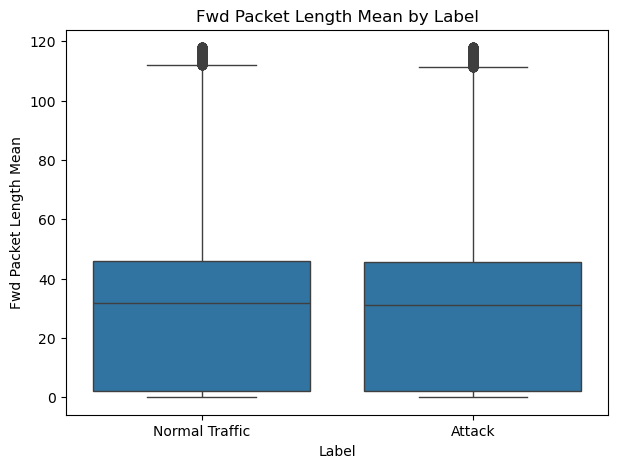

In [38]:
# Creating boxplot of Fwd Packet Length Mean grouped by Label

plt.figure(figsize=(7, 5))
sns.boxplot(data=boxplot_df, x='Label', y='Fwd Packet Length Mean')
plt.title("Fwd Packet Length Mean by Label")
plt.xlabel("Label")
plt.ylabel("Fwd Packet Length Mean")
plt.show()

The boxplot shows the distribution of Fwd Packet Length Mean for Normal Traffic and Attack traffic. After removing outliers, the plot becomes clearer and easier to compare. The difference in the box positions and spread shows that packet length behaviour is different between the two traffic categories.

## Hypothesis Testing

A hypothesis test is performed to check whether there is a significant difference in the mean Flow Duration between Normal Traffic and Attack classes.

**Null Hypothesis (H0):** There is no significant difference in mean Flow Duration between Normal Traffic and Attack.

**Alternative Hypothesis (H1):** There is a significant difference in mean Flow Duration between Normal Traffic and Attack.

In [39]:
# Separating Flow Duration values based on Label

normal_flow = new_df[new_df['Label'] == 'Normal Traffic']['Flow Duration']
attack_flow = new_df[new_df['Label'] == 'Attack']['Flow Duration']

In [40]:
# Performing independent t-test

t_stat, p_value = ttest_ind(normal_flow, attack_flow, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 5.445978058092922
P-value: 5.156997265813904e-08


In [41]:
# Interpreting the hypothesis test result

if p_value < 0.05:
    print("We reject the null hypothesis.")
    print("There is a significant difference in mean Flow Duration between Normal Traffic and Attack.")
else:
    print("We fail to reject the null hypothesis.")
    print("There is no significant difference in mean Flow Duration between Normal Traffic and Attack.")

We reject the null hypothesis.
There is a significant difference in mean Flow Duration between Normal Traffic and Attack.


The hypothesis test compares the mean Flow Duration of Normal Traffic and Attack traffic. If the p-value is less than 0.05, the null hypothesis is rejected, meaning there is a statistically significant difference between the two traffic categories. If the p-value is greater than or equal to 0.05, the null hypothesis is not rejected.

# Conclusion

In this coursework, the network traffic dataset was analysed using Python. The dataset was first understood by checking its structure, columns, and label categories. After that, required columns were selected, missing values were removed, duplicate records were dropped, and label values were renamed as Normal Traffic and Attack.

Summary statistics were calculated for Flow Duration and Packet Length Mean. Correlation analysis and a heatmap were used to understand relationships between numeric variables. Data exploration was performed using bar chart, pie charts, and boxplot. Finally, a hypothesis test was conducted to check whether there is a significant difference in mean Flow Duration between Normal Traffic and Attack classes.

Overall, the prepared dataset and analysis provide useful understanding of network traffic characteristics and can support further data mining or classification work.